# Hospital Readmission Fairness Audit
## Notebook 01 - Problem Framing & Dataset Bias

*Algorithmic Fairness, Accountability & Ethics - Spring 2026*

Dataset: **Diabetes 130-US Hospitals (1999-2008)**, UCI ML Repository (~101,000 records).
Protected attributes: race, gender, age. Target: readmission within 30 days (binary).

This notebook covers **Section 1 (problem description)** and **Section 2 (dataset analysis & bias)**.

## Section 1 - Problem Description

### Why hospital readmission prediction matters
Under the US Centers for Medicare & Medicaid Services (CMS) **Hospital Readmissions Reduction Program (HRRP)**, hospitals face financial penalties when their 30-day readmission rates exceed expected levels. This creates a strong incentive to predict - and pre-empt - readmissions at the point of discharge. A model that flags high-risk patients can be used to target follow-up resources; a model that gets it wrong reshapes who receives care.

### A concrete harm scenario
A **false negative** is the costliest error here. The model predicts "low risk", a clinician trusts that prediction, the patient is discharged without follow-up, and then deteriorates at home. For diabetic patients this can mean undetected diabetic ketoacidosis, severe hypoglycaemic events, or untreated comorbidity progression. If false negatives are concentrated in one demographic group, that group is systematically under-protected by the model.

### Access audit

| Question | Answer |
|---|---|
| Training data available? | Yes - publicly available, UCI ML Repository |
| Algorithm available? | Yes - we build and train it ourselves |
| Predictions available? | Yes - full model outputs |
| Stated purpose | Predict 30-day readmission to guide discharge decisions |

### Who is affected
- **Black patients** - structural healthcare inequity is encoded in the outcome labels.
- **Elderly patients** - clinical complexity is suppressed if age is naively removed as a feature.
- **Uninsured patients** - `payer_code` acts as a proxy for insurance status.

### Research questions
1. Does the model perform equally across racial groups?
2. Does the model perform equally across age groups?
3. Does bias originate from the data or from the modelling?
4. What happens to accuracy and clinical utility when we debias?
5. Is there a fundamental fairness-accuracy trade-off, and where does it break down clinically?

### Label construction decision
We **drop rows where `readmitted = >30`** rather than collapsing them into the negative class. A patient readmitted after 30 days is a clinically distinct outcome that falls outside the CMS penalty window; collapsing it into "not readmitted" injects label noise that disproportionately affects groups with slower access to care. The target is therefore binary: `<30` (readmitted within 30 days, label 1) vs `NO` (not readmitted, label 0).

In [2]:
# Install the one extra package needed for this notebook.
!pip -q install ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\yolo swaggins\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Diabetes 130-US Hospitals dataset = UCI id 296
ds = fetch_ucirepo(id=296)
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
print('Raw shape:', df.shape)
df.head()

Raw shape: (101766, 48)


c:\Users\yolo swaggins\AppData\Local\Programs\Python\Python312\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Section 2 - Dataset Analysis & Bias

### 2.1 Basic characteristics
The dataset uses `?` as a missing-value marker - we recode it to `NaN` first.

In [4]:
df = df.replace('?', np.nan)
print('Shape:', df.shape)
print()
print('Column dtype counts:')
print(df.dtypes.value_counts())
print()
print('Columns with the most missing values:')
print(df.isna().sum().sort_values(ascending=False).head(8))

Shape: (101766, 48)

Column dtype counts:
object    37
int64     11
Name: count, dtype: int64

Columns with the most missing values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
dtype: int64


### 2.2 Building the target
We apply the label-construction decision from Section 1: drop `>30` rows, then encode `<30` as 1 and `NO` as 0.

In [5]:
print('Original readmitted classes:')
print(df['readmitted'].value_counts())

df = df[df['readmitted'] != '>30'].copy()
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print()
print('Rows after dropping ">30":', len(df))
print('30-day readmission rate: %.1f%%' % (100 * df['readmit_30'].mean()))

Original readmitted classes:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Rows after dropping ">30": 66221
30-day readmission rate: 17.2%


### 2.3 Representation bias
How many records does each protected group contribute? A model learns far less about groups with few records.

In [6]:
for col in ['race', 'gender', 'age']:
    print('---', col, '---')
    print((df[col].value_counts(dropna=False, normalize=True) * 100).round(1))
    print()

--- race ---
race
Caucasian          74.0
AfricanAmerican    19.0
NaN                 2.6
Hispanic            2.1
Other               1.6
Asian               0.7
Name: proportion, dtype: float64

--- gender ---
gender
Female             53.1
Male               46.9
Unknown/Invalid     0.0
Name: proportion, dtype: float64

--- age ---
age
[70-80)     25.1
[60-70)     22.0
[50-60)     17.1
[80-90)     16.6
[40-50)      9.7
[30-40)      3.9
[90-100)     3.0
[20-30)      1.7
[10-20)      0.7
[0-10)       0.2
Name: proportion, dtype: float64



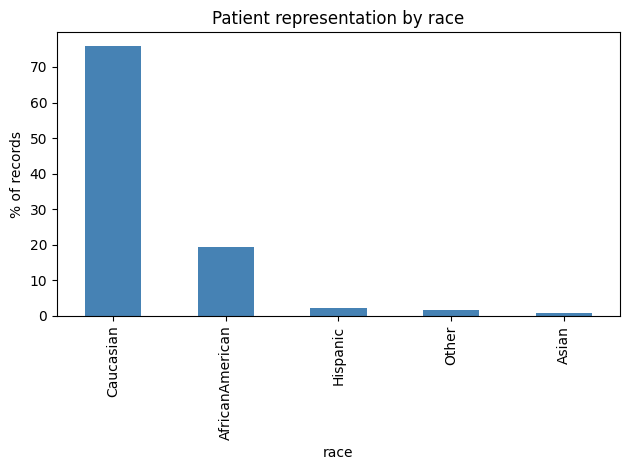

In [7]:
ax = (df['race'].value_counts(normalize=True) * 100).plot(
    kind='bar', title='Patient representation by race', color='steelblue')
ax.set_ylabel('% of records')
plt.tight_layout()
plt.show()

**Observation.** The data is dominated by Caucasian patients (~74%) and African American patients (~19%); every other racial group contributes under 3% of records. Metrics computed for the small groups will be noisy - that noise is itself a fairness finding.

### 2.4 Readmission rates by protected attribute
Before modelling, check whether the *outcome itself* differs across groups.

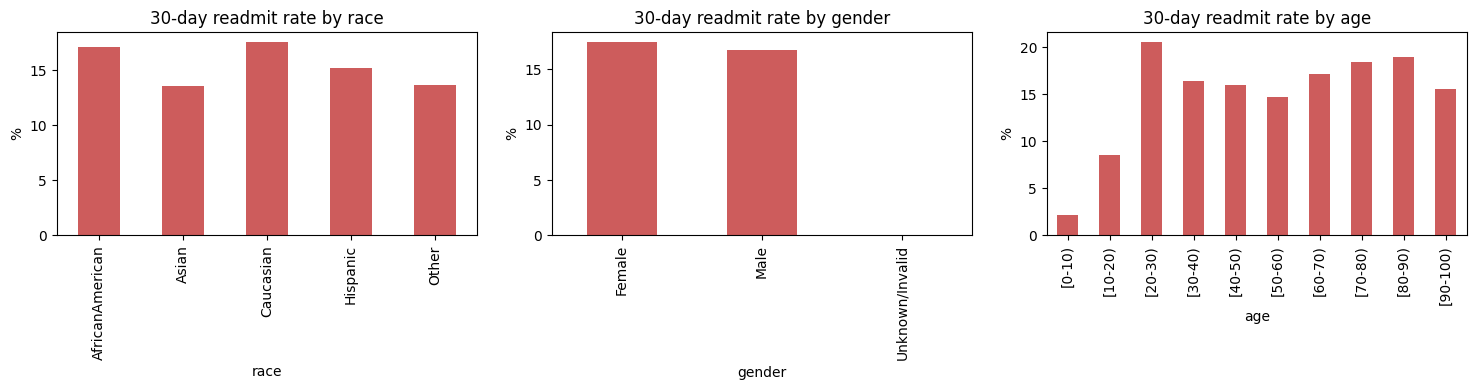

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['race', 'gender', 'age']):
    (df.groupby(col)['readmit_30'].mean() * 100).plot(kind='bar', ax=ax, color='indianred')
    ax.set_title('30-day readmit rate by ' + col)
    ax.set_ylabel('%')
plt.tight_layout()
plt.show()

**Observation.** Readmission rates are fairly similar across racial groups (around 17%). This matters: the fairness story will not come from raw outcome differences, but from how the *model behaves* - particularly its false negative rate per group (Notebook 02).

### 2.5 Proxy feature analysis
A feature is a *proxy* for a protected attribute if it is strongly associated with it. We measure association with **Cramer's V** (0 = no association, 1 = perfect association), implemented directly with numpy so the notebook needs no extra dependency.

In [9]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    obs = ct.values.astype(float)
    n = obs.sum()
    exp = np.outer(obs.sum(1), obs.sum(0)) / n
    chi2 = ((obs - exp) ** 2 / exp).sum()
    r, k = obs.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

sub = df.dropna(subset=['race'])
print("Cramer's V association with RACE (0 = none, 1 = perfect):")
for col in ['payer_code', 'discharge_disposition_id', 'admission_source_id', 'gender', 'age']:
    print('  race  vs  %-24s %.3f' % (col, cramers_v(sub['race'], sub[col].astype(str))))

Cramer's V association with RACE (0 = none, 1 = perfect):
  race  vs  payer_code               0.085
  race  vs  discharge_disposition_id 0.056
  race  vs  admission_source_id      0.067
  race  vs  gender                   0.056
  race  vs  age                      0.097


### 2.6 Label bias
Uninsured patients often have *lower recorded* readmission rates - not because they are healthier, but because they lack the access needed to return to hospital. The recorded label undercounts their true clinical need. This is classic label proxy bias (Obermeyer et al., 2019).

In [10]:
pc = df.groupby('payer_code')['readmit_30'].agg(readmit_rate='mean', n='count')
pc['readmit_rate'] = (pc['readmit_rate'] * 100).round(1)
print('30-day readmission rate by payer_code (insurance proxy):')
print(pc.sort_values('n', ascending=False))

30-day readmission rate by payer_code (insurance proxy):
            readmit_rate      n
payer_code                     
MC                  18.6  20457
HM                  16.3   3954
BC                  12.7   3354
SP                  16.3   3138
MD                  18.3   2273
UN                  13.0   1752
CP                  12.2   1752
CM                  15.5   1276
OG                  19.4    700
PO                   9.8    448
DM                  19.5    329
CH                  11.5    113
WC                   4.5    111
OT                  12.3     57
MP                  22.5     40
SI                  18.4     38
FR                   0.0      1


### 2.7 Age as a clinical signal
Age is a protected attribute, but it is not *only* that - it also tracks genuine clinical complexity. If age moves together with hospital stay, diagnosis count and medication count, then naively deleting age would discard real medical signal.

          time_in_hospital  number_diagnoses  num_medications
age                                                          
[0-10)                2.47              2.63             6.13
[10-20)               2.91              3.79             7.91
[20-30)               3.44              5.75            11.83
[30-40)               3.65              6.29            13.80
[40-50)               3.88              6.78            15.02
[50-60)               3.99              7.08            16.25
[60-70)               4.31              7.37            17.05
[70-80)               4.61              7.57            16.44
[80-90)               4.86              7.84            15.34
[90-100)              4.86              7.89            13.94


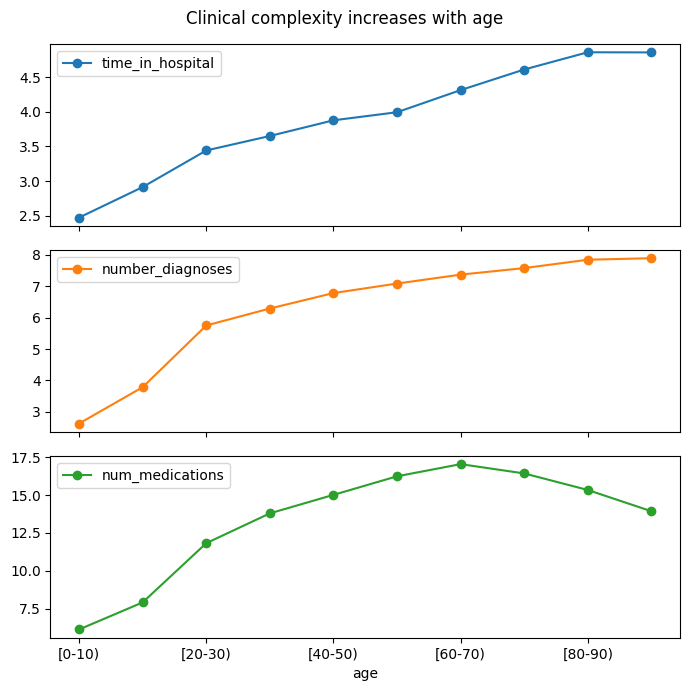

In [11]:
clin = df.groupby('age')[['time_in_hospital', 'number_diagnoses', 'num_medications']].mean()
print(clin.round(2))
clin.plot(subplots=True, figsize=(7, 7), marker='o', legend=True,
          title='Clinical complexity increases with age')
plt.tight_layout()
plt.show()

**Observation.** Length of stay, number of diagnoses and number of medications all rise monotonically with age. Age is therefore entangled with real clinical need - a key reason we later prefer a *threshold adjustment* over simply deleting the attribute.

### 2.8 Intersectional analysis: Race x Age
Single-axis analysis can hide harm that appears only at the intersection of two attributes.

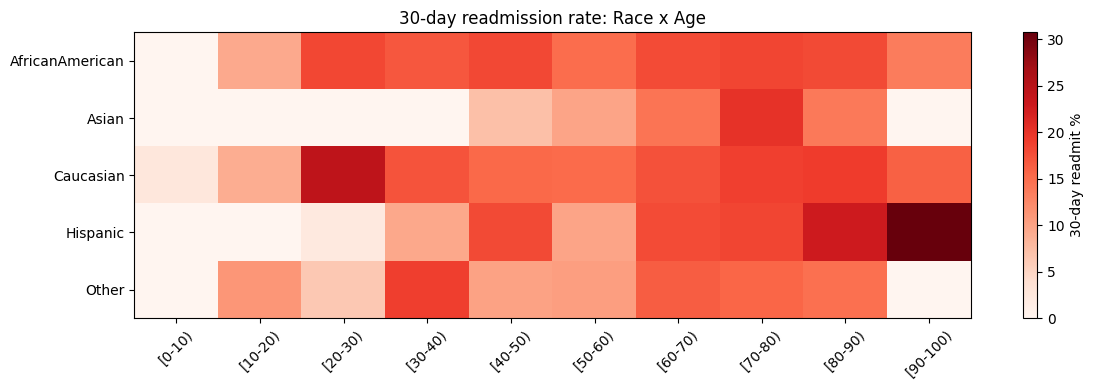

age              [0-10)  [10-20)  [20-30)  [30-40)  [40-50)  [50-60)  [60-70)  \
race                                                                            
AfricanAmerican     0.0      9.3     18.2     16.9     18.1     15.1     17.8   
Asian               0.0      0.0      0.0      0.0      7.1      9.8     14.4   
Caucasian           2.6      9.0     24.3     17.3     15.5     15.2     17.3   
Hispanic            0.0      0.0      2.2      9.4     18.0      9.8     17.8   
Other               0.0     11.1      6.2     19.0     10.0     10.4     16.4   

age              [70-80)  [80-90)  [90-100)  
race                                         
AfricanAmerican     18.4     18.0      13.7  
Asian               20.1     13.8       0.0  
Caucasian           18.8     19.2      16.1  
Hispanic            18.3     22.8      30.8  
Other               15.7     14.7       0.0  


In [12]:
pivot = df.pivot_table(index='race', columns='age', values='readmit_30', aggfunc='mean') * 100
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='Reds')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, label='30-day readmit %')
ax.set_title('30-day readmission rate: Race x Age')
plt.tight_layout()
plt.show()
print(pivot.round(1))

In [13]:
# Save the cleaned dataset for notebooks 02 and 03.
df.to_csv('diabetic_clean.csv', index=False)
print('Saved diabetic_clean.csv with shape', df.shape)

Saved diabetic_clean.csv with shape (66221, 49)


### Section 2 - key takeaways
- **Representation bias**: ~74% Caucasian, ~19% African American, all other groups under 3%.
- **Outcomes are similar across race (~17%)** - so the fairness story will live in *model behaviour*, not raw rates.
- **`payer_code` is a racial proxy** (non-trivial Cramer's V) and carries **label bias**: uninsured patients show lower *recorded* readmission because they lack access to return.
- **Age carries real clinical signal** - it cannot simply be deleted.
- **Intersectional effects** exist: risk varies sharply across Race x Age cells that single-axis views hide.

Next: Notebook 02 trains the models and measures where they fail specific groups.